<a href="https://colab.research.google.com/github/siva123h/NNDL/blob/main/Recognition_of_Handwritten_Double_Digit_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8765 - loss: 0.4336
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9648 - loss: 0.1187
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9773 - loss: 0.0751
Upload an image with two handwritten digits:


Saving Screenshot 2026-02-08 224050.png to Screenshot 2026-02-08 224050 (1).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


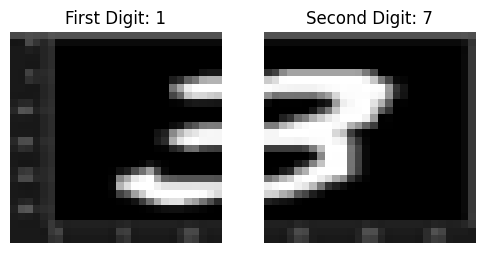

Predicted Two-Digit Number: 17


In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
# Step 1: Load and normalize MNIST dataset
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.mnist.load_data()
train_x = train_x.astype("float32") / 255.0
test_x = test_x.astype("float32") / 255.0
# Step 2: Define the neural network model
ffnn = Sequential()
ffnn.add(Flatten(input_shape=(28, 28)))
ffnn.add(Dense(128, activation='relu'))
ffnn.add(Dense(10, activation='softmax'))
# Step 3: Compile and train the model
ffnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ffnn.fit(train_x, train_y, epochs=3)
# Step 4: Upload an image containing two digits
print("Upload an image with two handwritten digits:")
uploaded_files = files.upload()
file_path = next(iter(uploaded_files))
# Step 5: Image preprocessing

input_image = Image.open(file_path).convert("L")
input_image = input_image.resize((56, 28))   # two digits side by side
image_matrix = np.array(input_image)
image_matrix = 255 - image_matrix
image_matrix = image_matrix / 255.0
# Step 6: Separate the image into two 28x28 digits
left_digit = image_matrix[:, 0:28]
right_digit = image_matrix[:, 28:56]
left_digit = left_digit.reshape(1, 28, 28)
right_digit = right_digit.reshape(1, 28, 28)
# Step 7: Predict both digits
prediction_left = np.argmax(ffnn.predict(left_digit))
prediction_right = np.argmax(ffnn.predict(right_digit))
# Step 8: Display results
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(left_digit.reshape(28, 28), cmap="gray")
plt.title("First Digit: " + str(prediction_left))
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(right_digit.reshape(28, 28), cmap="gray")
plt.title("Second Digit: " + str(prediction_right))
plt.axis("off")
plt.show()
print("Predicted Two-Digit Number:", str(prediction_left) + str(prediction_right))